# Churn

La retención de clientes es un factor clave en la rentabilidad de cualquier empresa, ya que el costo de adquisición de nuevos clientes suele ser significativamente mayor que el de mantener los existentes.

En este proyecto se desarrolla un modelo de machine learning orientado a predecir la probabilidad de churn, entendiendo churn como la pérdida o abandono del cliente. A través del análisis de variables comportamentales y transaccionales, se busca identificar clientes en riesgo y habilitar estrategias proactivas de retención.


## Descripcion de Variables.
Variable objetivo:

* 1 = Churn (Cliente con posibilidad de abandono)
* 0 = No Churn (Cliente retenido)

* gender = Género del cliente (Male / Female)

* SeniorCitizen = Indica si el cliente es adulto mayor (1 = Sí, 0 = No)

* Partner = Si el cliente tiene pareja (Yes / No)

* Dependents = Si el cliente tiene dependientes (Yes / No)

* tenure = Tiempo (en meses) que el cliente lleva con la empresa.

* PhoneService = Si tiene servicio telefónico

* MultipleLines = Si tiene múltiples líneas telefónicas

* InternetService = Tipo de servicio de internet (DSL/Fiber optic /No)

* OnlineSecurity = Seguridad en línea

* OnlineBackup = Respaldo en la nube

* DeviceProtection = Protección de dispositivos

* TechSupport = Soporte técnico

* StreamingTV = Servicio de TV

* StreamingMovies = Servicio de películas

* Contract = Tipo de contrato. (Month-to-month /One year /Two year)

* PaperlessBilling = Facturación digital.

* PaymentMethod =Método de pago. (Electronic check / Mailed check / Bank transfer / Credit card)

* MonthlyCharges = Cargo mensual del cliente

* TotalCharges = Total pagado por el cliente



* Las variables incluyen características demográficas, servicios contratados, tipo de contrato y comportamiento de facturación, lo que permite analizar el churn desde múltiples dimensiones: comportamiento del cliente, nivel de engagement y factores económicos.

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import make_scorer
from sklearn.utils import shuffle
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score,log_loss, make_scorer
from category_encoders import TargetEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
pd.set_option('display.max_columns', None)
from category_encoders import WOEEncoder
from sklearn import set_config
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline

#set_config(transform_output="pandas")

In [2]:
df = pd.read_csv(r'C:\Users\jabes\Desktop\PORTAFOLIO CIENTIFICO DE DATOS\CHURN\playground-series-s6e3\train.csv')
df.drop(columns='id', inplace=True)
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [3]:
print(f"{df.info()}")
print('*=' * 30)
print(f"{df.isna().sum()}")
print('\n *=' * 30)
print(f"{df.isnull().sum()}")
print('*='*30)
print(f"{df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

* En el DataSet no existen Null's y ni Nan, tenemos muchas variables discretas no numericas las mismas requeriran transformacion, algunas binarias.

# Iniciando EDA

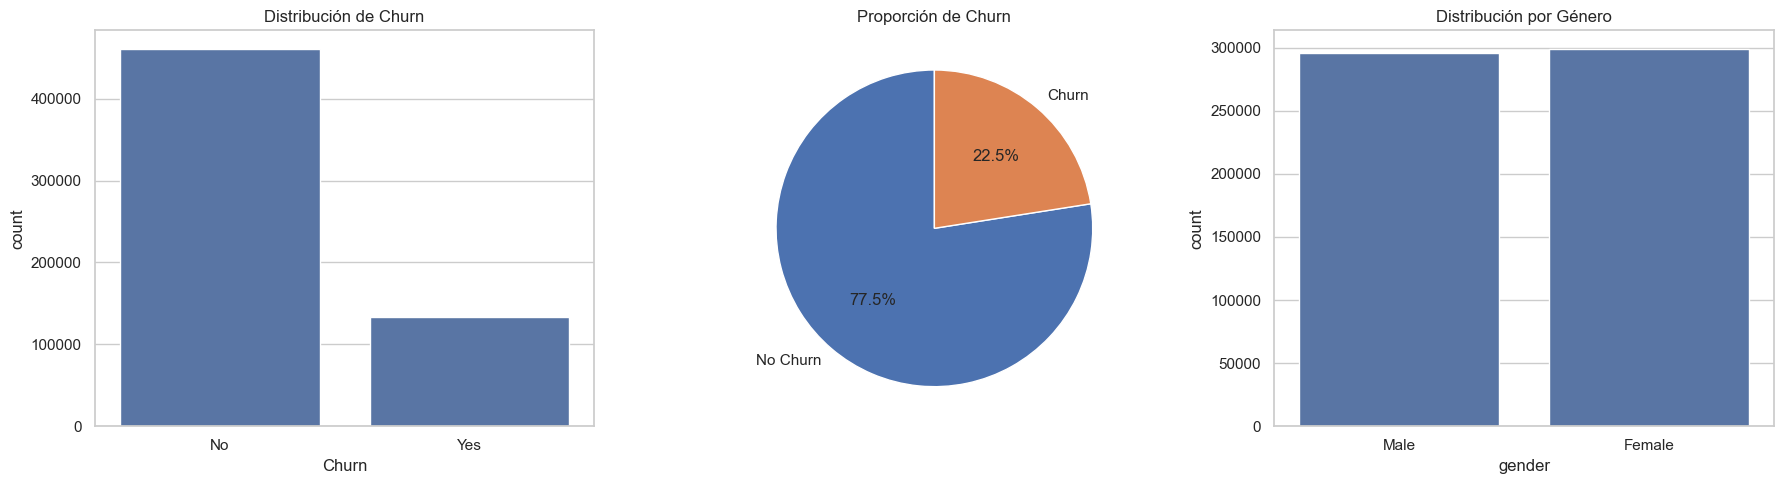

Churn
No     460377
Yes    133817
Name: count, dtype: int64
******************************
gender
Female    50.276172
Male      49.723828
Name: proportion, dtype: float64


In [4]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Churn
sns.countplot(x='Churn', data=df, ax=axes[0])
axes[0].set_title('Distribución de Churn')


# Pie Chart (Churn)
churn_counts = df['Churn'].value_counts()
axes[1].pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proporción de Churn')


# Género

sns.countplot(x='gender', data=df, ax=axes[2])
#axes[2].set_yscale('log')
axes[2].set_title('Distribución por Género')

# Ajustar espacios
plt.tight_layout()
plt.show()

print(df['Churn'].value_counts())
print('**'*15)
print(df['gender'].value_counts(normalize=True)*100)

* El dataset presenta desbalance (22.5% churn vs 77.5% no churn), lo cual deberá considerarse en el modelado.

## Describe

In [5]:
def describe_modif(df):
    num_df = df.select_dtypes(include='number')
    desc = num_df.describe()
    desc.loc['count ceros'] = (num_df == 0).sum()
    desc.loc['count negativos'] = (num_df < 0).sum()
    desc.loc['count null'] = num_df.isna().sum()
    desc.loc['pct ceros'] = (num_df == 0).mean()
    desc.loc['pct negativos'] = (num_df < 0).mean()
    desc.loc['pct nulls'] = num_df.isna().mean()
    desc.loc['Coef. Variacion'] = desc.loc['std'] / desc.loc['mean']
    q1 = desc.loc['25%']
    q3 = desc.loc['75%']
    iqr = q3 - q1
    desc.loc['IQR'] = iqr
    outliers = ((num_df < (q1 - 1.5 * iqr))|(num_df > (q3 + 1.5 * iqr))).sum()
    desc.loc['Conteo de Outliers'] = outliers
    desc.loc['Asimetria'] = num_df.skew()
    percentiles = [0, 0.25,0.50, 0.75, 0.90,0.97, 0.98, 0.99,1]
    for p in percentiles:
        desc.loc[f'P{int(p*100)}'] = num_df.quantile(p)
    desc = desc.drop(index=['min','25%','50%','75%', 'max'])
    return desc.round(2)

describe_modif(df)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.00,594194.00,594194.00,594194.00
mean,0.11,36.58,65.87,2494.38
std,0.32,25.06,31.07,2353.92
count ceros,526395.00,0.00,0.00,0.00
count negativos,0.00,0.00,0.00,0.00
count null,0.00,0.00,0.00,0.00
pct ceros,0.89,0.00,0.00,0.00
pct negativos,0.00,0.00,0.00,0.00
pct nulls,0.00,0.00,0.00,0.00
Coef. Variacion,2.79,0.69,0.47,0.94


# Distribucion de Variables Numericas.

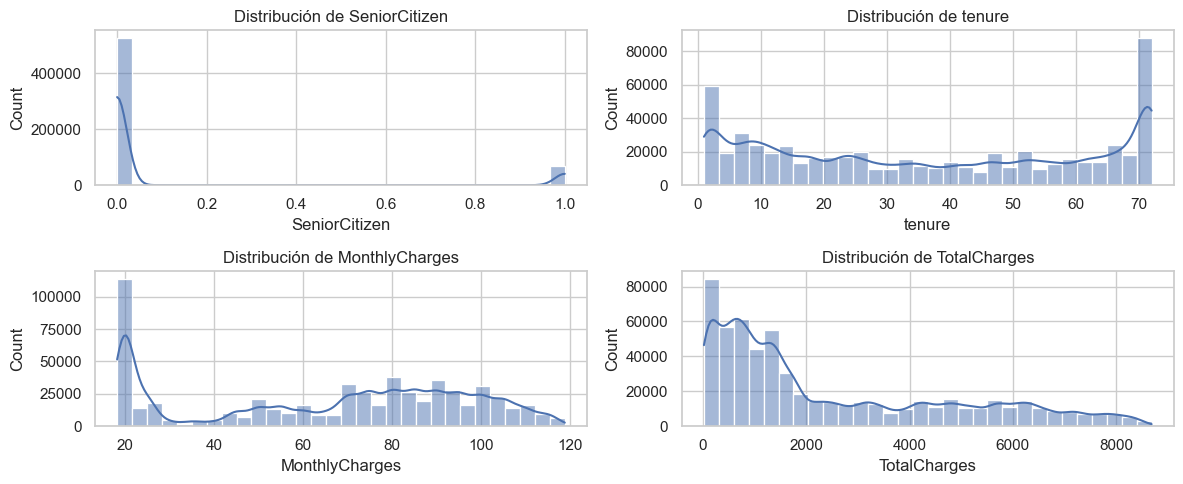

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12,5))

numerical_col = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']

for i, col in enumerate(numerical_col):
    row = i // 2
    col_idx = i % 2

    sns.histplot(df[col], bins=30, kde=True, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

# Observaciones Variables Numericas:

* La variable **SeniorCitizen** es una variable binaria, la cual indica que tenemos una poblacion en su mayoria joven.

* En **MonthlyCharges** confirmo la presencia de algunos bayes y Outliers, podria monstrar algun patron de subcripciones aumento de subscripciones en meses especificos.

* En **TotalCharges** se muestra una grafica decreciente con una fuerte concentracion de 0 a 1900 USD, cabe destacar que esta variable es medida en USD, tambien podria indicar que algunos clientes se atrasan levemente.

* En **Ternure** confirmo la existencia de Outliers los mismos indican una retencion balanceada por clientes viejos mostrando clientes que tienen mas de 70 meses con el servicio contratado, pero tambien muestra una gran masa de clientes que son nuevos y se tendria que buscar los puntos fuertes para hacer que duren en el tiempo.

# Distribucion de Variables Categoricas.

In [7]:
categorical_cols= df.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ["Churn", "gender"]]

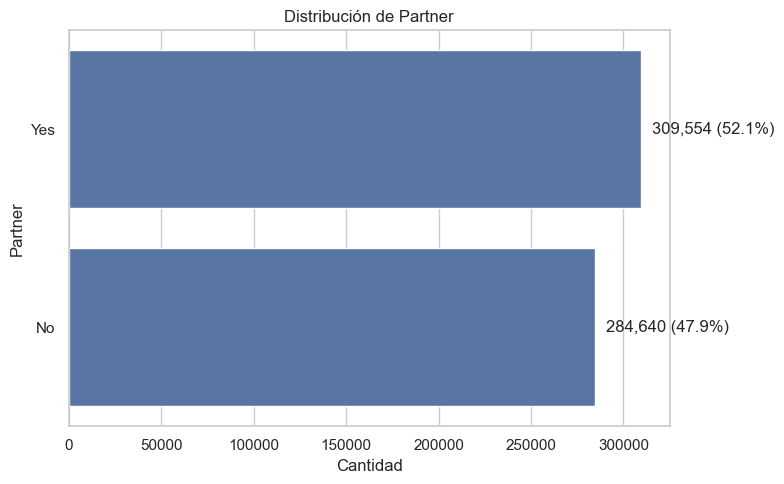

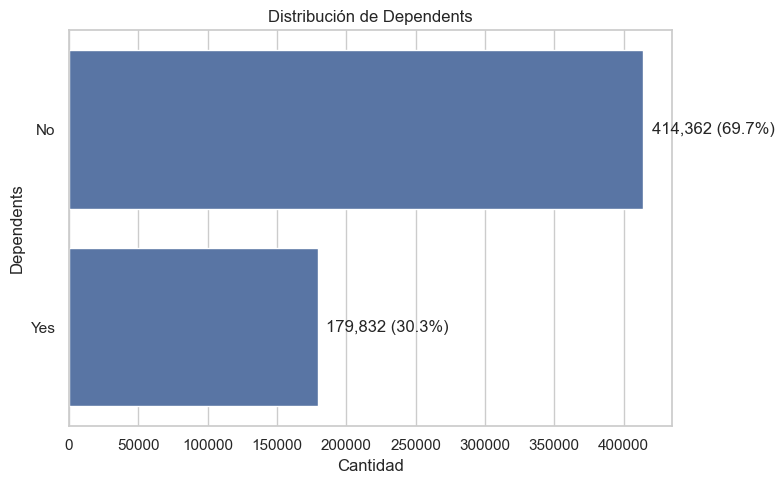

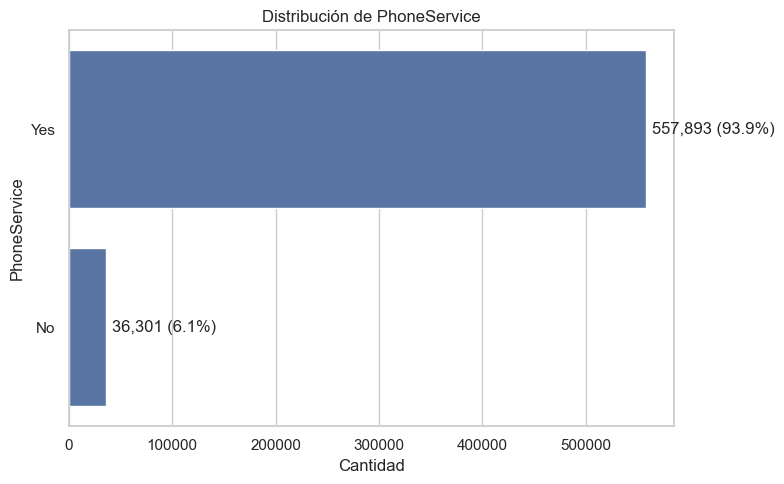

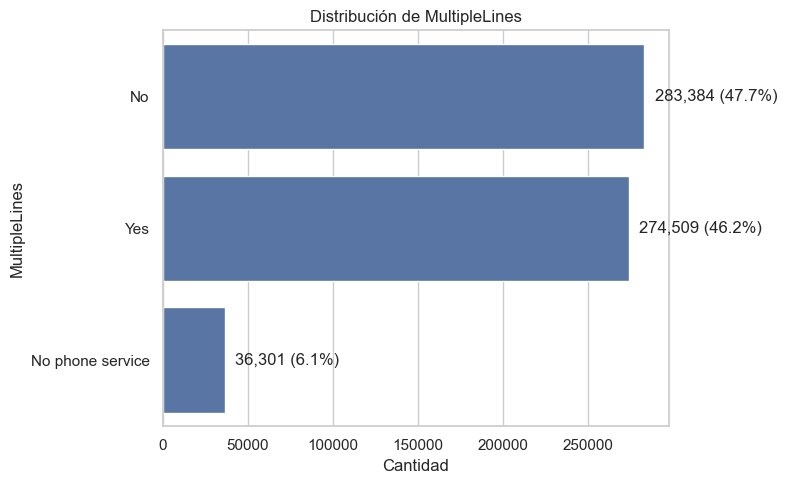

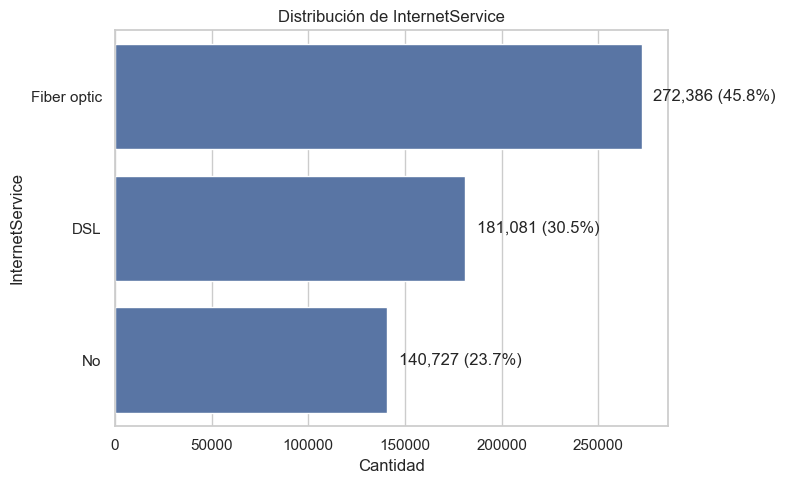

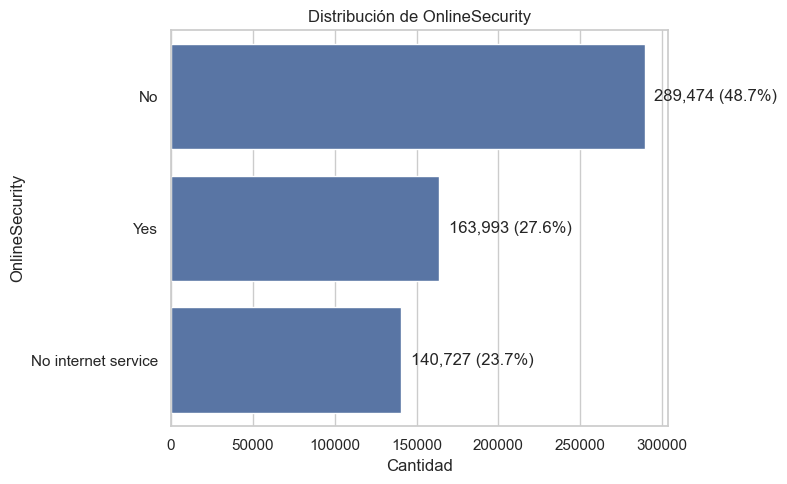

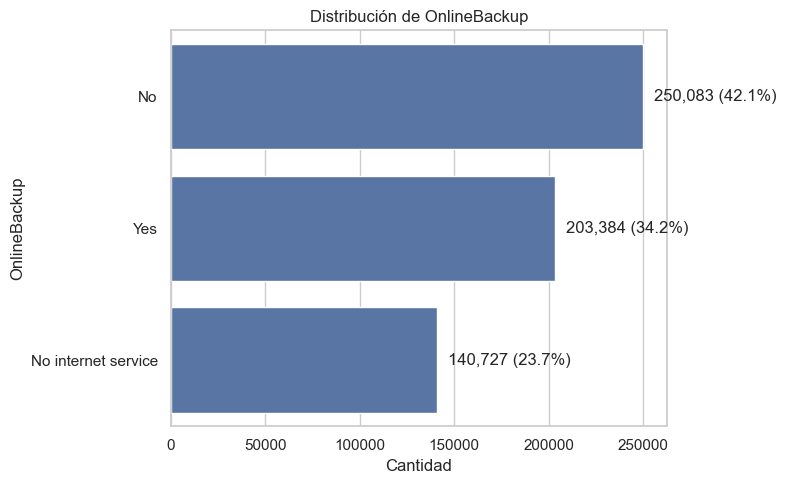

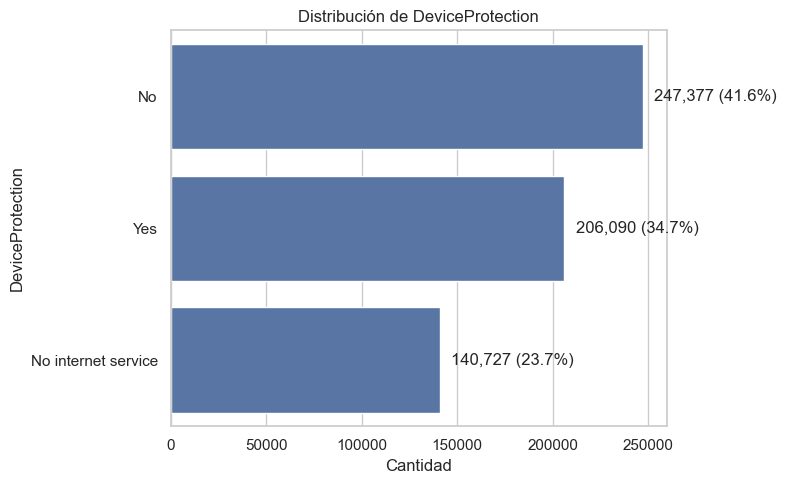

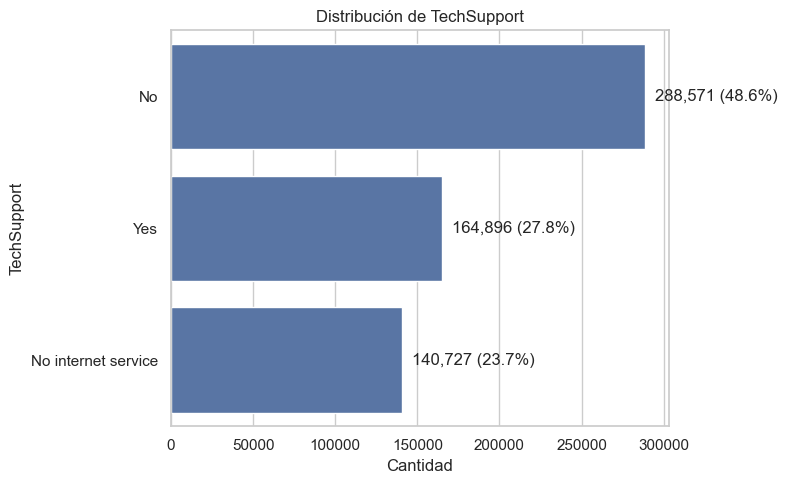

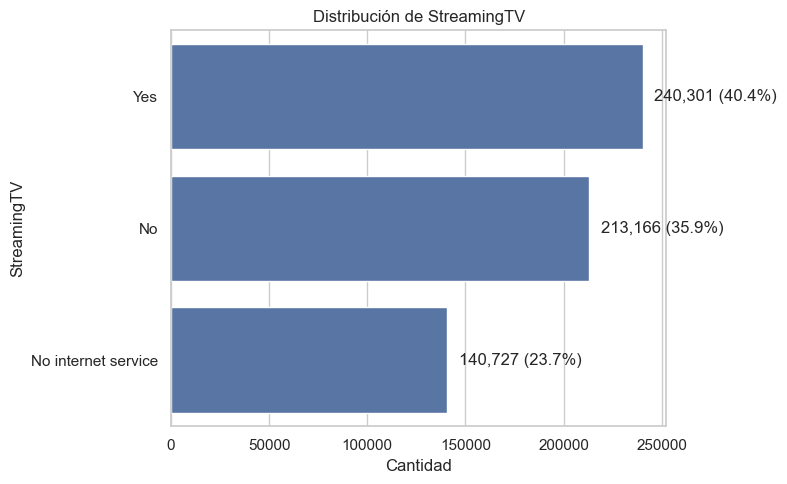

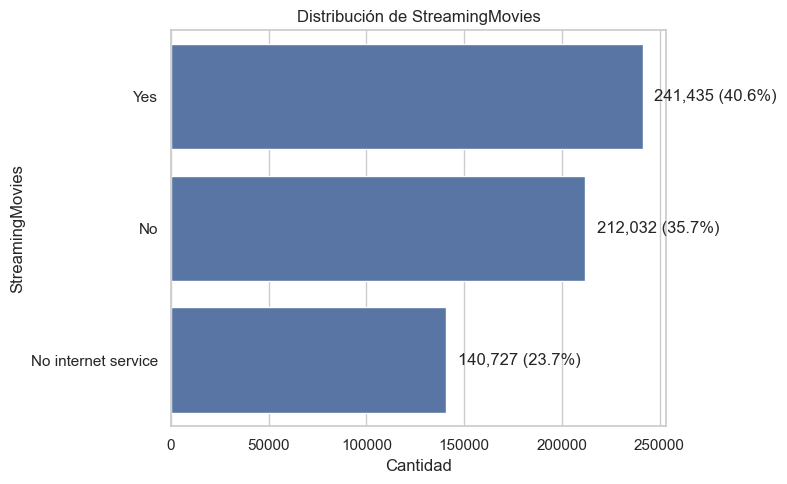

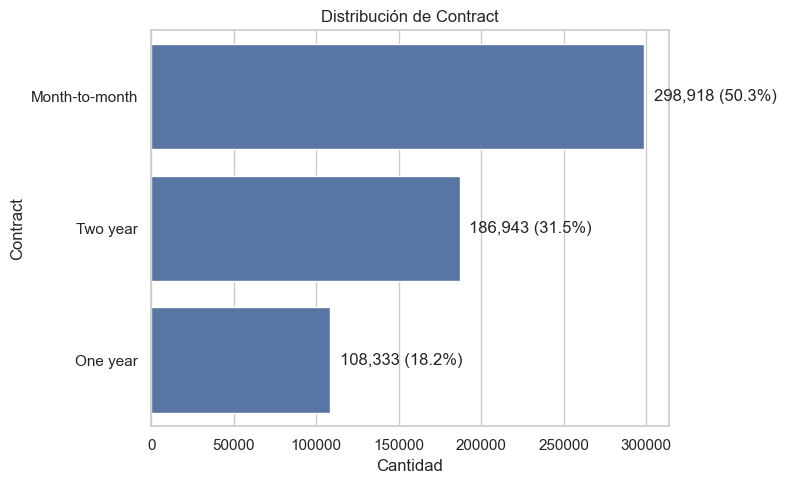

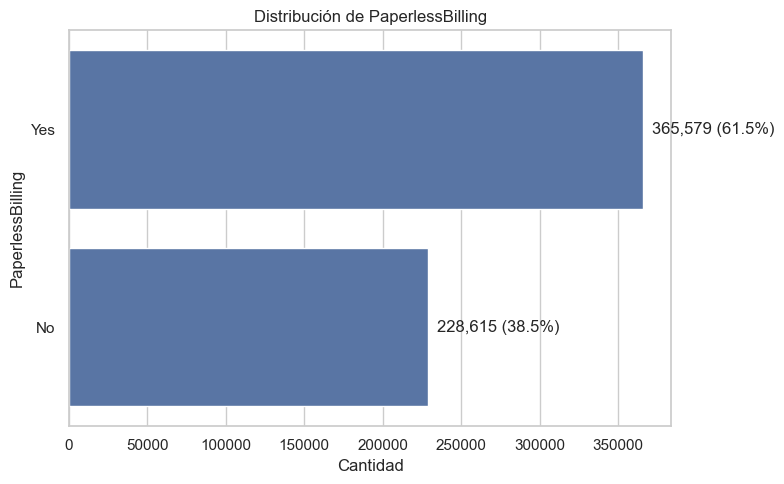

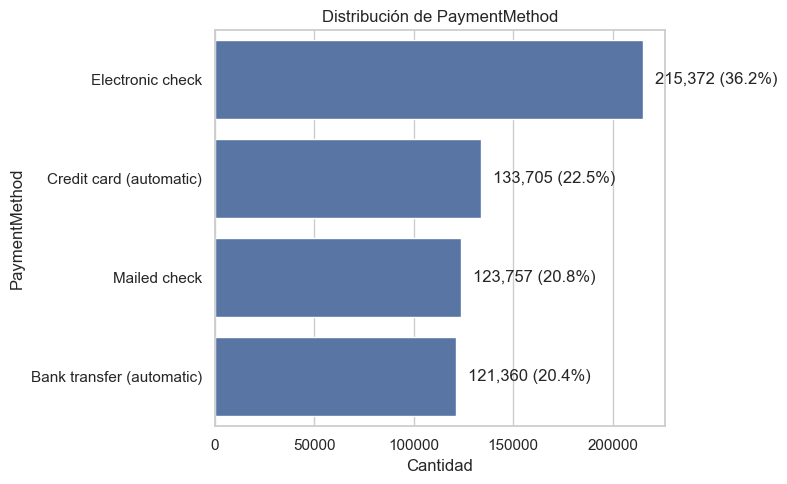

In [8]:
for col in categorical_cols:
    plt.figure(figsize=(8,5))

    # Conteo
    counts = df[col].value_counts()
    total = len(df)

    # Crear barplot horizontal
    ax = sns.barplot(x=counts.values, y=counts.index)

    # Agregar labels con % y count
    for i, v in enumerate(counts.values):
        pct = (v / total) * 100
        ax.text(v + (total * 0.01), i, f'{v:,} ({pct:.1f}%)', va='center')

    plt.title(f'Distribución de {col}')
    plt.xlabel('Cantidad')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## Observaciones de Variables Categóricas

* **Churn:** Se observa un fuerte desbalance en las clases, notando que el 22.5% de la población corresponde a clientes que abandonan el servicio brindado.
* **PaymentMethod:** El método de pago con mayor uso es **Electronic Check**, pero la utilización de los otros canales de pago (**Credit Card (automatic)**, **Bank Transfer**, **Mailed Check**) da indicios de que tenemos clientes que pertenecen a una población menos madura.
* **PaperlessBilling:** Más del 60% de los clientes tienen facturación digital. Sería interesante analizar el comportamiento de esta variable frente al **Churn**.
* **Contract:** Más del 50.3% de los clientes utilizan contratación mes a mes, lo que sugiere que son productos de suscripción. También se observa que el 31.5% de la clientela tiene un contrato de 2 años, indicando que podrían ser empresas.
* **StreamingMovies:** Esta variable confirma claramente que es una población relativamente joven. También levanta sospechas el hecho de que el 23.7% no tiene servicio de internet.
* **DeviceProtection:** Este servicio no es muy demandado, solo el 37.7% de la población lo tiene, mientras que el 23.7% muestra que no tiene internet.
* **OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, InternetService:** Todas estas variables tienen algo en común que es una constante interesante: el 23.7% de su población no tiene suscrito el servicio de internet. Esto da a entender que existe una parte de la población que carece del servicio base, o bien, es una población madura que no presenta necesidad de este.
* **PhoneService:** El 94% de la población presenta servicio de teléfono.
* **gender:** La distribución entre géneros es normal y balanceada.
* **MultipleLines:** Más del 46% de los clientes poseen múltiples líneas de servicio contratado. Sería bueno analizar esta distribución con respecto a **Churn**.

# Analisis bivariado.

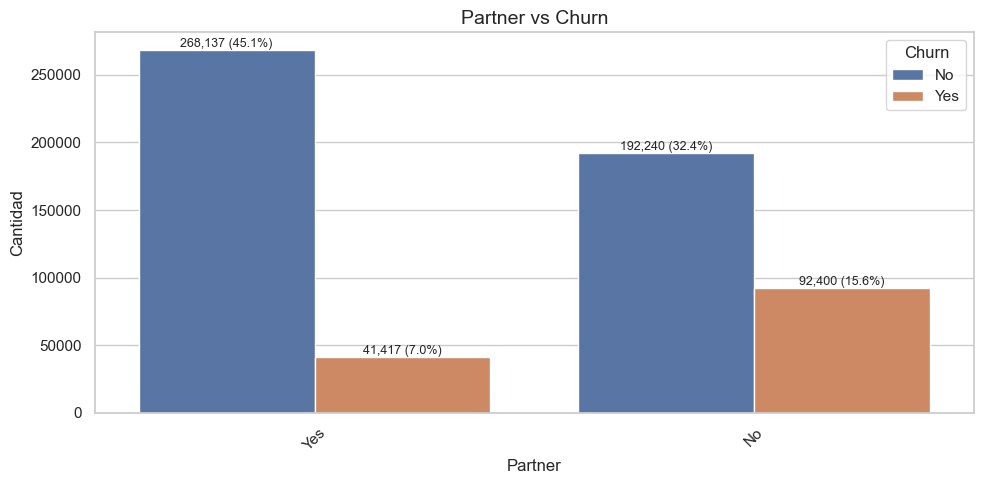

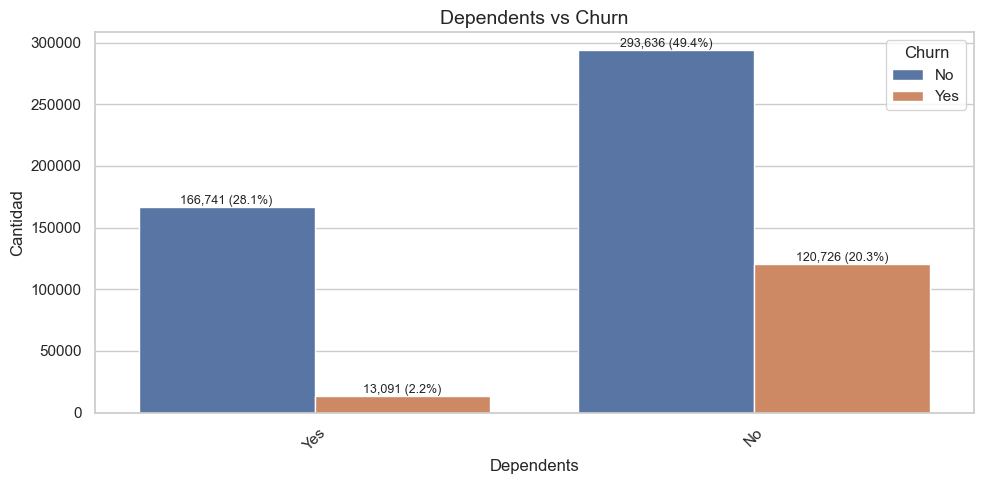

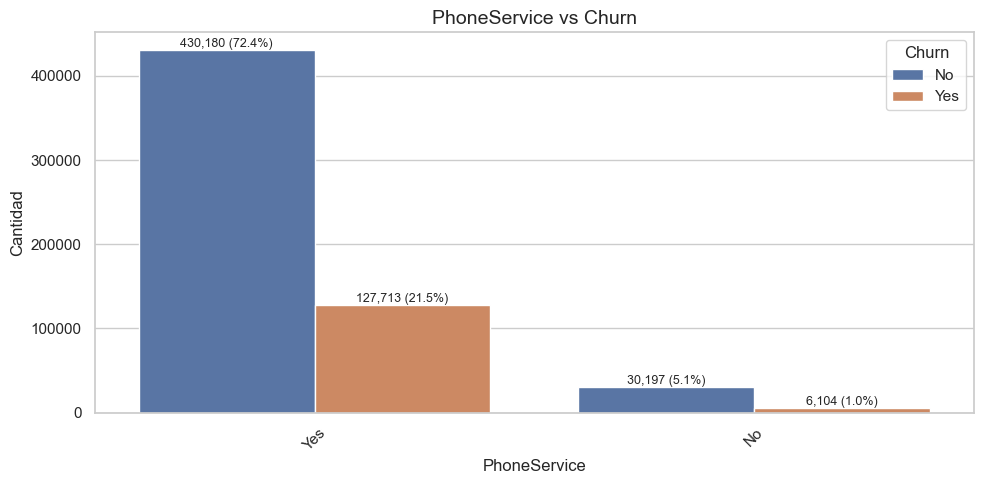

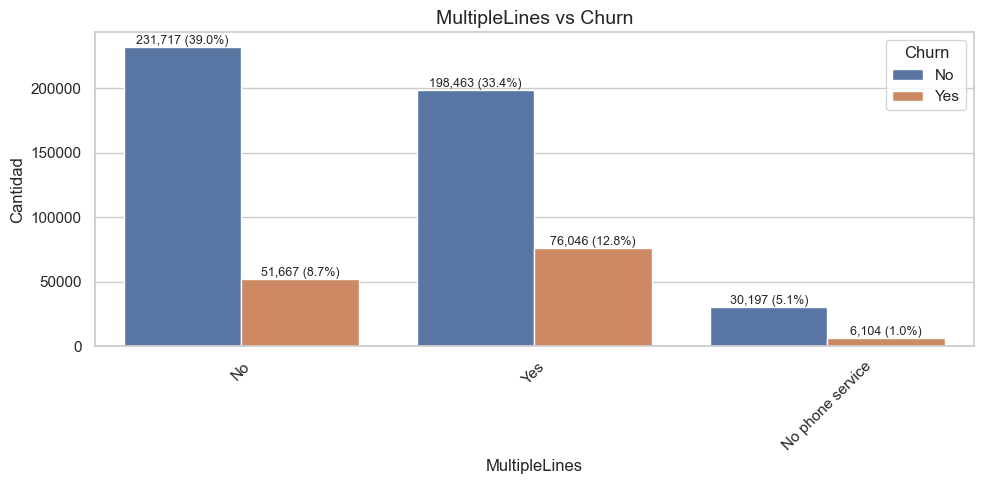

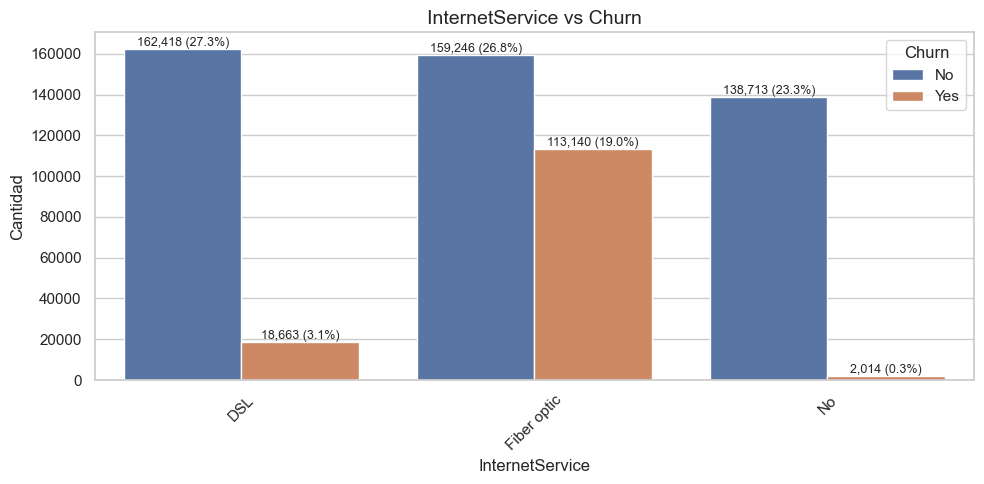

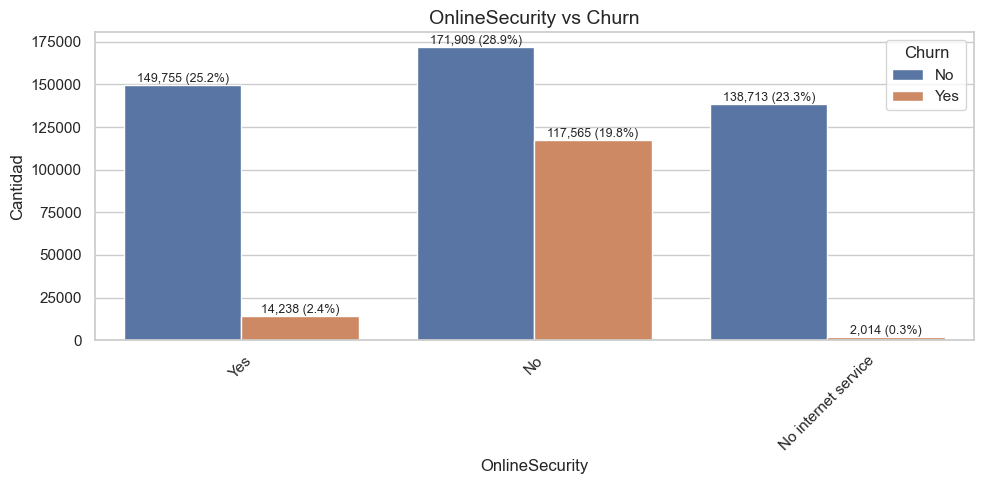

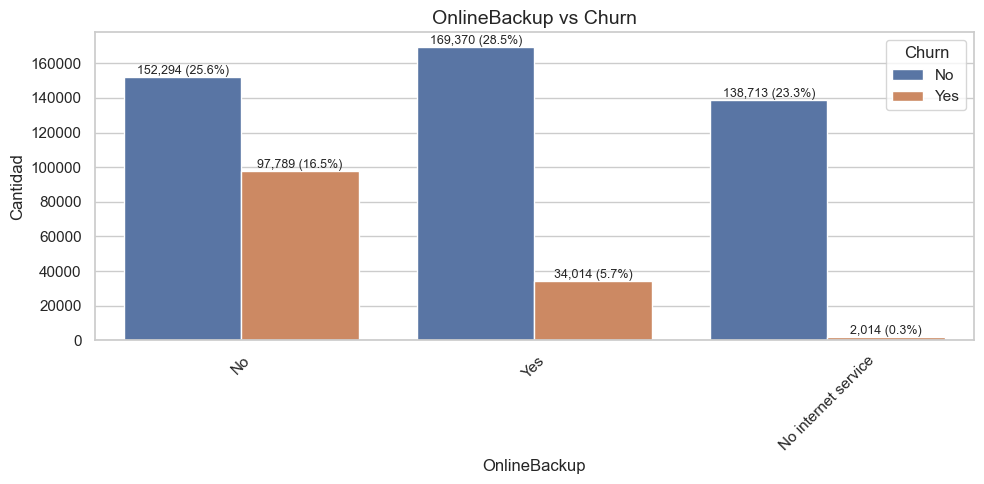

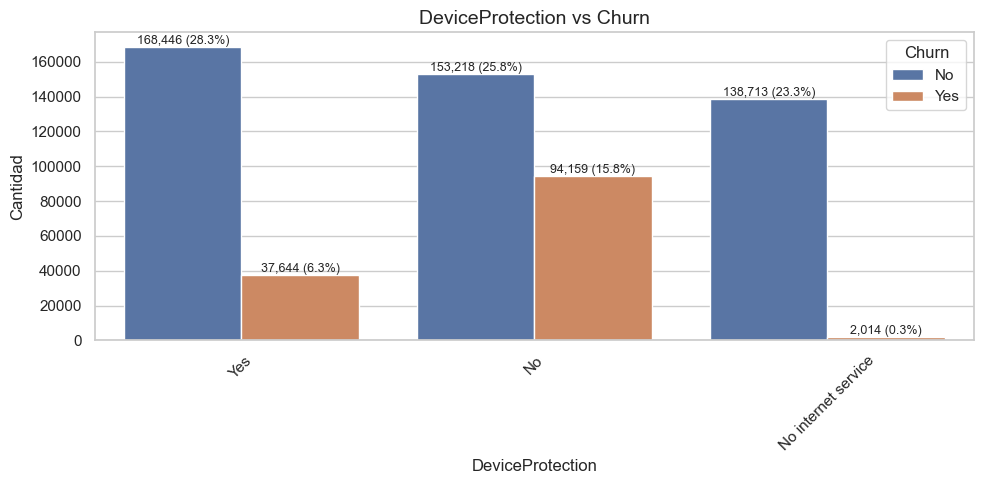

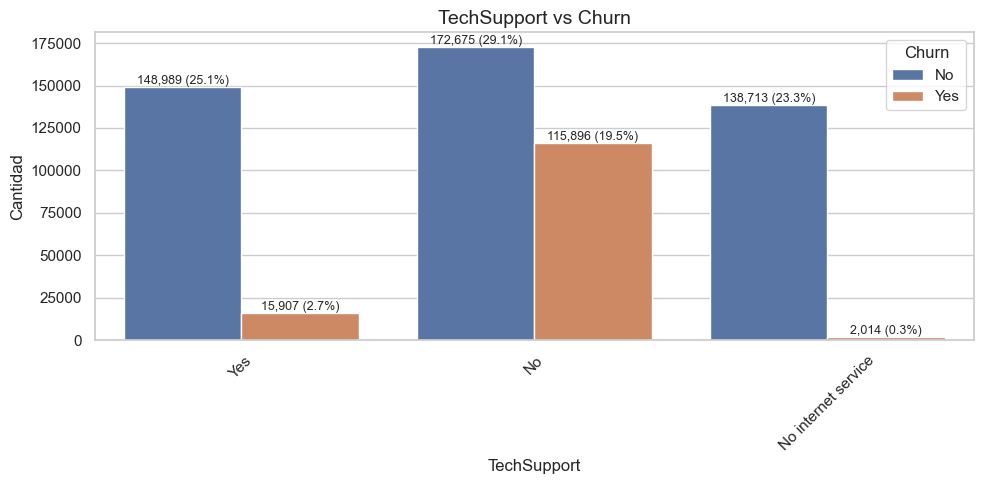

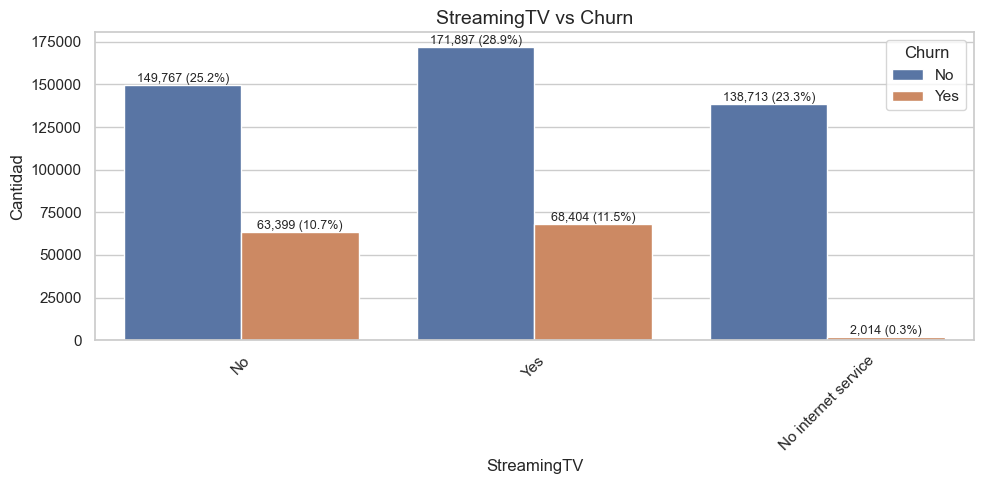

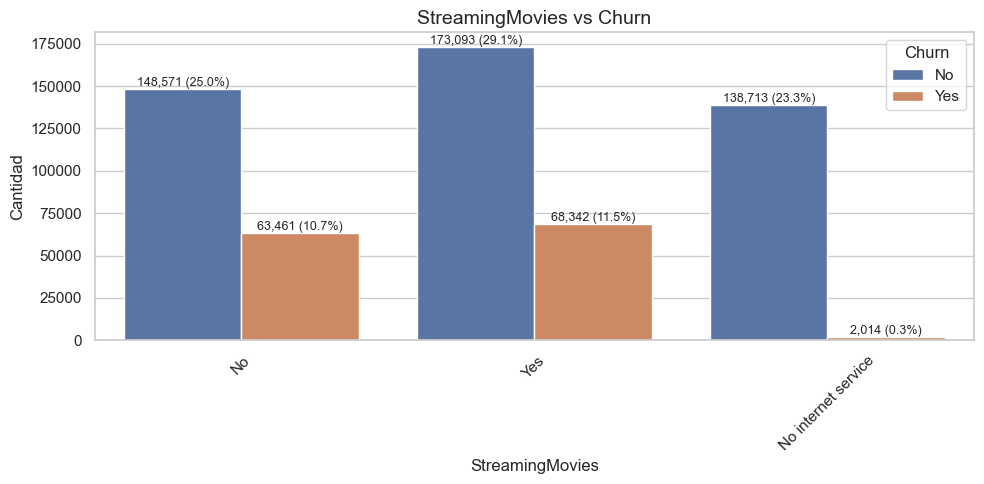

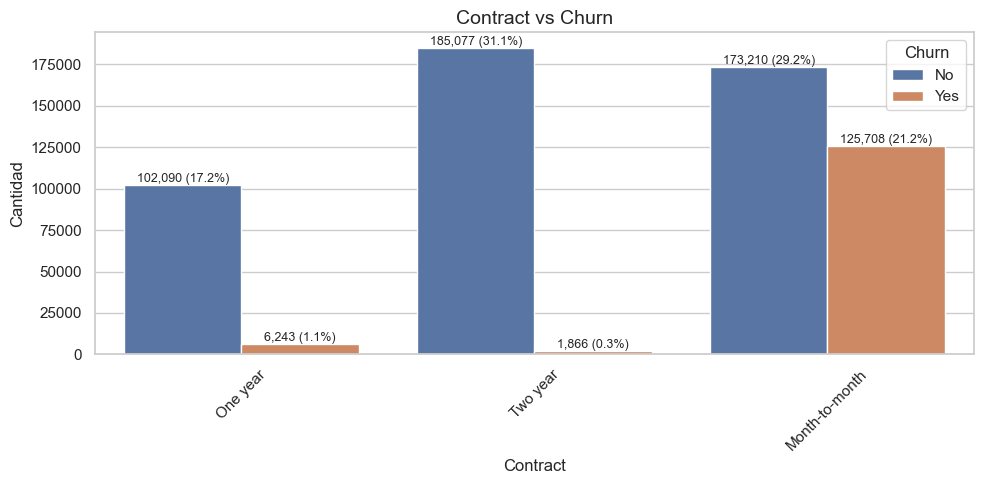

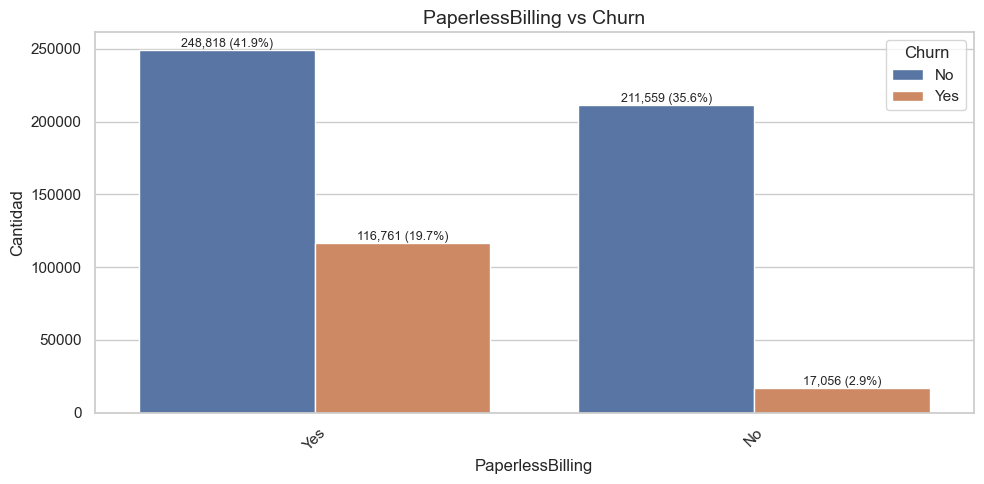

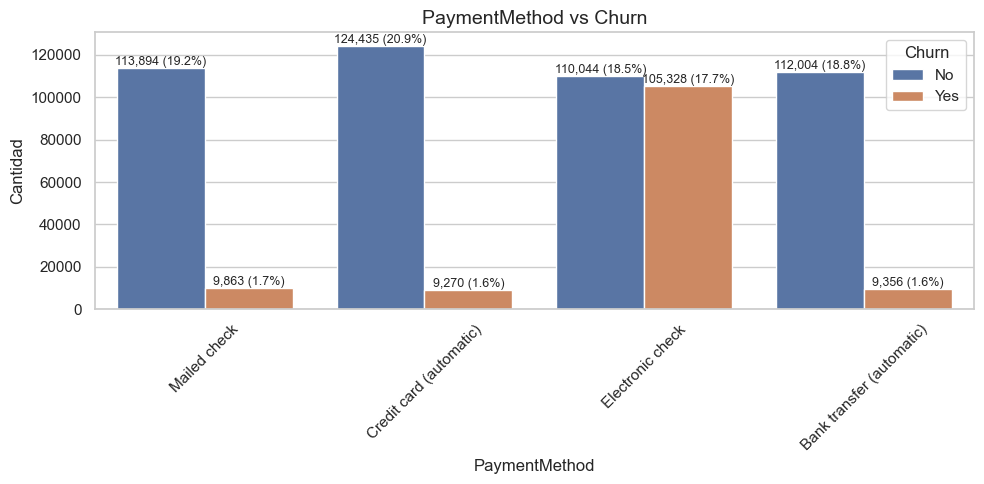

In [9]:
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    ax = sns.countplot(x=col, hue='Churn', data=df)
    total = len(df)

    # recorrer cada grupo de barras
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if height == 0:
                continue
            pct = (height / total) * 100
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f'{int(height):,} ({pct:.1f}%)',
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.title(f'{col} vs Churn', fontsize=14)
    plt.xticks(rotation=45)
    plt.ylabel('Cantidad')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

* **MultiplesLines** indica que las personas con multiples lineas tienen un 13% de probablidad de cancelar el servicio, este comportamiento podria ser dado a saturacion de servicios contratados.

* **InternetService** esta variable me parece bastante interesante al hacer la comparativa con la variable objetivo, mostrando que dentro de la población dada los que tienen el servicio de Fiber Optic son los que tienen mas probabilidad de cancelar el mismo, esto quizas es dado a alguna inconformidad con el servicio siento este el 10% de la población.

* **OnlineSecurity** esta variable Tambien refleja un patron anomalo, el 19.8% de la población tiene alta probabilidad de churn porque no tiene servicio de Seguridad contratado, esto podria referirse a un patron de fraude.

* **PaymentMethod** el grafico confirmo algo que me llama bastante la atención, la gran masa de clientes con probabilidad de churn tienen el método de pago **Electrinic Check** esto representa el 17.7% de la población, luego de esto todos los otros métodos de pago reflejan menos del 1.8% de probabilidad de churn.

* **Contract** al ver esta variable contra churn se confirma que los clientes que pagan mes a mes son los que tienen mayor probabilidad de irse, en cambio los que tienen contratos mas largos tienen menos probabilidad, lo ideal seria ver la posibilidad de realizar contratos mas largos para poder reducir esto.

* **TechSuport & DeviceProtection** son variables muy similares en comportamiento, las mimas reflejan una alta posibilidad de churn en clientes que no cuentan con estos servicios.

* **InternetService** el churn en los clientes con Fibra Optica es bastante alto, representando esto el 19% de la población, vale la pena destacar que este servicio es Premium cuando lo comparamos con el DSL.

* **Dependents** las ciudadanos sin dependientes reflejan el 20.3% de la población churn del dataset.

# Challenge de Encoding para validar Cual es Mejor Opcion(Encoding Binario, OHT, WoE)

In [10]:

y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn'])

# Columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = X.select_dtypes(exclude=['object']).columns.tolist()

# Train / Test split (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Función KS (la mantengo igual)
def ks_statistic(y_true, y_prob):
    df_ks = pd.DataFrame({'y': y_true, 'prob': y_prob})
    df_ks = df_ks.sort_values('prob')
    df_ks['cum_good'] = (df_ks['y'] == 0).cumsum() / (df_ks['y'] == 0).sum()
    df_ks['cum_bad']  = (df_ks['y'] == 1).cumsum() / (df_ks['y'] == 1).sum()
    return np.max(np.abs(df_ks['cum_good'] - df_ks['cum_bad']))

# ====================== PIPELINES ======================

#  One Hot Encoding + Escalado
ohe_pipe = Pipeline([
    ('preprocess', ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])),
    ('model', LogisticRegression(max_iter=1000))
])

# Target Encoding + Escalado
tg_pipe = Pipeline([
    ('preprocess', ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', TargetEncoder(), categorical_cols)
    ])),
    ('model', LogisticRegression(max_iter=1000))
])

#  WOE Encoding
woe_pipe = Pipeline([
    ('preprocess', ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', WOEEncoder(), categorical_cols)
    ])),
    ('model', LogisticRegression(max_iter=1000))
])


pipelines = {
    "OHE": ohe_pipe,
    "Target Encoding": tg_pipe,
    "WOE (Librería)": woe_pipe
}

results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)

    results.append({
        'Model': name,
        'AUC': roc_auc_score(y_test, y_prob),
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'KS': ks_statistic(y_test, y_prob)
    })

# Resultados finales
results_df = pd.DataFrame(results).sort_values(by='AUC', ascending=False)
display(results_df)

,Model,AUC,Accuracy,F1,KS
0,OHE,0.908408,0.854450,0.670527,0.665079
2,WOE (Librería),0.908299,0.854316,0.670887,0.665440
1,Target Encoding,0.907981,0.854400,0.671002,0.665992


A manera de prueba realice un test entre varios metodos de encoding, todos dieron casi el mismo resultado, de los que escogi utilizare el WoE.

---

## HetMap antes de Transformaciones.

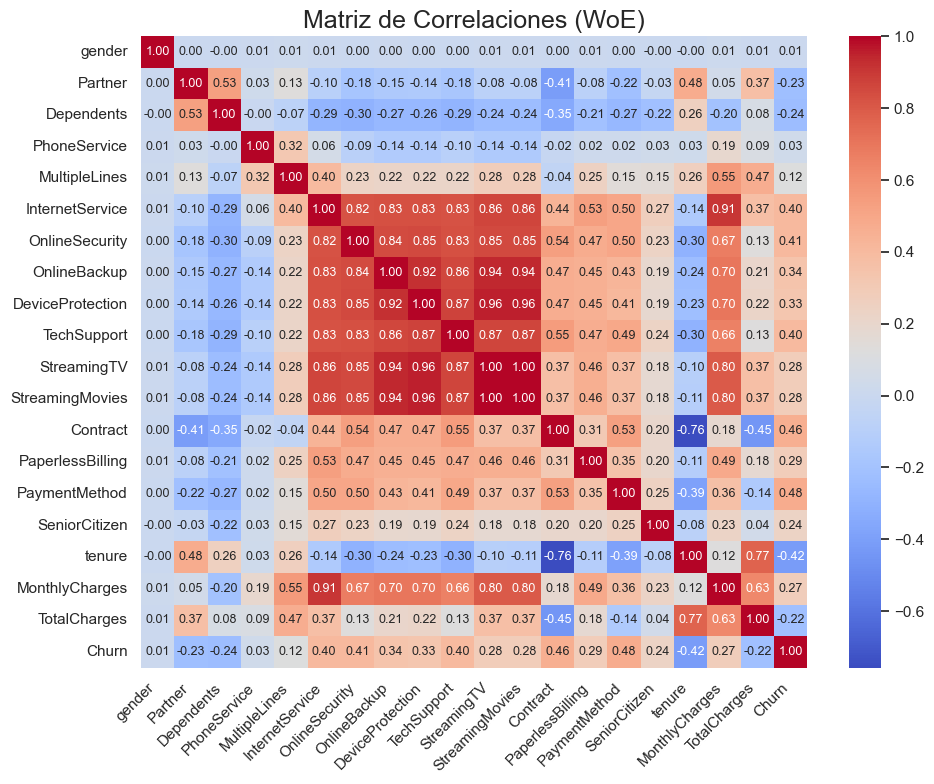


 Correlaciones más fuertes con Churn (antes de Feature Engineering):
Churn               1.0000
PaymentMethod       0.4762
Contract            0.4581
tenure              0.4185
OnlineSecurity      0.4082
InternetService     0.4038
TechSupport         0.3968
OnlineBackup        0.3439
DeviceProtection    0.3302
PaperlessBilling    0.2851
StreamingMovies     0.2816
StreamingTV         0.2815
MonthlyCharges      0.2730
Dependents          0.2404
SeniorCitizen       0.2364
Partner             0.2282
TotalCharges        0.2184
MultipleLines       0.1152
PhoneService        0.0348
gender              0.0068
Name: Churn, dtype: float64


In [11]:
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1}).astype(int)

y = df['Churn']
X = df.drop(columns='Churn')

# Convertir variables binarias Yes/No a 0/1
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in X.columns and X[col].dtype == 'object':
        X[col] = X[col].map({'Yes': 1, 'No': 0}).astype(int)

# Columnas originales (antes del Feature Engineering)
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

#  Verificación
missing = [col for col in cat_cols + num_cols if col not in X.columns]


#  Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('woe', WOEEncoder(), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop'
)

#  Transformar
X_transformed = preprocessor.fit_transform(X, y)

#  Crear DataFrame
df_en = pd.DataFrame(X_transformed, columns=cat_cols + num_cols)
df_en['Churn'] = y.reset_index(drop=True)

#  Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_en.corr()



sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    annot_kws={"size": 9})



plt.title('Matriz de Correlaciones (WoE)', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Ranking de correlaciones
print("\n Correlaciones más fuertes con Churn (antes de Feature Engineering):")
print(corr_matrix['Churn'].abs().sort_values(ascending=False).round(4))

##  Observaciones de Correlacion.

### Perfil Demográfico
* **Gender:** No muestra ninguna correlación relevante con el resto de las variables ni con la variable objetivo (*Churn*). Su correlación con Churn es prácticamente nula (~0.01), lo que sugiere que el género no es un factor asociado al abandono.
* **Partner & Dependents:** Presentan una correlación moderada positiva (0.53). Los clientes con pareja tienden a tener dependientes con mayor frecuencia.
* **SeniorCitizen:** Muestra correlaciones moderadas con varios servicios y una correlación positiva moderada con *Churn* (~0.24). Los adultos mayores presentan un perfil de riesgo distinto al resto de la población.

### Servicios y Cargos
* **Saturación de Servicios:** Existe un bloque de correlaciones muy fuertes y positivas entre los servicios adicionales (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV y StreamingMovies), con valores que frecuentemente superan 0.80–0.96. Esta alta multicolinealidad indica una fuerte redundancia entre estas variables, por lo que será necesario aplicar técnicas de reducción de dimensionalidad, agrupación o creación de variables sintéticas.
* **MonthlyCharges e InternetService:** Presentan una correlación muy alta (0.91). Este vínculo es lógico, ya que el tipo de conexión a internet es uno de los principales determinantes del cargo mensual.
* **TotalCharges:** Muestra una fuerte correlación con **tenure** (0.77) y con **MonthlyCharges** (0.63), lo que hace referencia a una naturaleza acumulativa.
* **MonthlyCharges:** De forma aislada, presenta una correlación moderada con la variable objetivo *Churn*.

### Factores de Riesgo de Abandono (Churn)
* **Contract:** Muestra una correlación negativa clara con *Churn* (~ -0.35). Los contratos más cortos (*Month-to-month*) están asociados a mayor probabilidad de abandono. Además, presenta una fuerte correlación negativa con **tenure** (-0.76).
* **OnlineSecurity & TechSupport:** Muestran correlaciones negativas con *Churn* (alrededor de -0.30). Los clientes que no contratan estos servicios tienden a presentar mayor tasa de abandono.
* **PaymentMethod:** El método *Electronic check* presenta una correlación positiva notable con *Churn* (~0.48). Esta es una de las asociaciones más fuertes observadas.
* **PaperlessBilling:** Muestra una correlación positiva moderada (~0.29) con el abandono.

**CORRELACION NO INDICA CAUSALIDAD!!!!**

## ️ Feature Engineering: Propuestas de Transformación

Basado en las redundancias y correlaciones observadas, se proponen las siguientes transformaciones para enriquecer el dataset:

### Creación de la Variable `SAG` (Servicios Agregados)
Para simplificar la alta dimensionalidad y redundancia de los servicios adicionales, crearemos una variable sintética categórica:

* **`SAG = 1`**: Si el cliente tiene **más de 2** servicios adicionales contratados.
* **`SAG = 0`**: Si el cliente tiene **2 o menos** servicios adicionales contratados.

---

## Feature Engineering

In [12]:

servicio = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


diccionario_mapeo = {
    'Yes': 1,
    'No': 0,
    'No internet service': 0
}

# Sag
df['Sag'] = 0

for i in servicio:
    df[i] = df[i].map(diccionario_mapeo).fillna(0).astype(int)
    df['Sag'] += df[i]

df['Sag'] = (df['Sag'] > 2).astype(int)

# Is_New
df['Is_New'] = (df['tenure'] < 6).astype(int)

# tenure en rangos
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 100],
    labels=['0', '1', '2', '3']
)

# Avg_charges
df['Avg_Charges'] = df['TotalCharges'] / (df['tenure'] + 1)


# Cliente vulnerable
df['Vulnerable'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['TechSupport'] == 0)
).astype(int)

# Cliente de alto riesgo
df['High_Risk'] = (
    (df['tenure'] < 12) &
    (df['Contract'] == 'Month-to-month') &
    (df['PaymentMethod'] == 'Electronic check')
).astype(int)

# Eliminar las columnas originales que ya fueron transformadas o consolidadas
df.drop(columns=[
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'tenure','MonthlyCharges'
], inplace=True)


## Feature Engineering

Como se mencionó anteriormente, se creó la variable **SAG (Servicios Agregados)**. Esta variable binaria toma el valor de:

- **1**: clientes con más de dos servicios adicionales contratados.
- **0**: clientes con dos o menos servicios adicionales.

Esta transformación permite reducir la dimensionalidad agrupando múltiples variables relacionadas con servicios en una sola característica representativa.

La variable **Is_New** identifica clientes con menos de 6 meses dentro de la empresa. Este grupo representa clientes con mayor probabilidad de churn y sobre los cuales la empresa debería enfocar mayores esfuerzos de retención.

Se creó la variable **tenure_group** para segmentar la variable **tenure**, correspondiente al tiempo de permanencia del cliente en la empresa. Esta agrupación permite al modelo identificar patrones de abandono según el ciclo de vida del cliente.

La variable **Avg_Charges** calcula el promedio de pagos realizados por cliente en función de su permanencia, permitiendo identificar diferencias de comportamiento entre clientes de mayor y menor valor.

La variable **Vulnerable** fue creada para detectar clientes con contratos *Month-to-Month* y ausencia de servicios de soporte técnico. Esta combinación representa un perfil con mayor probabilidad de abandono.

Finalmente, la variable **High_Risk** identifica clientes con menos de un año en la empresa, contratos *Month-to-Month* y método de pago *Electronic Check*. Como se observó en el análisis exploratorio, este patrón está asociado a un mayor riesgo de churn.

---

## Mapa De Correlacion Luego De Feature Engineering

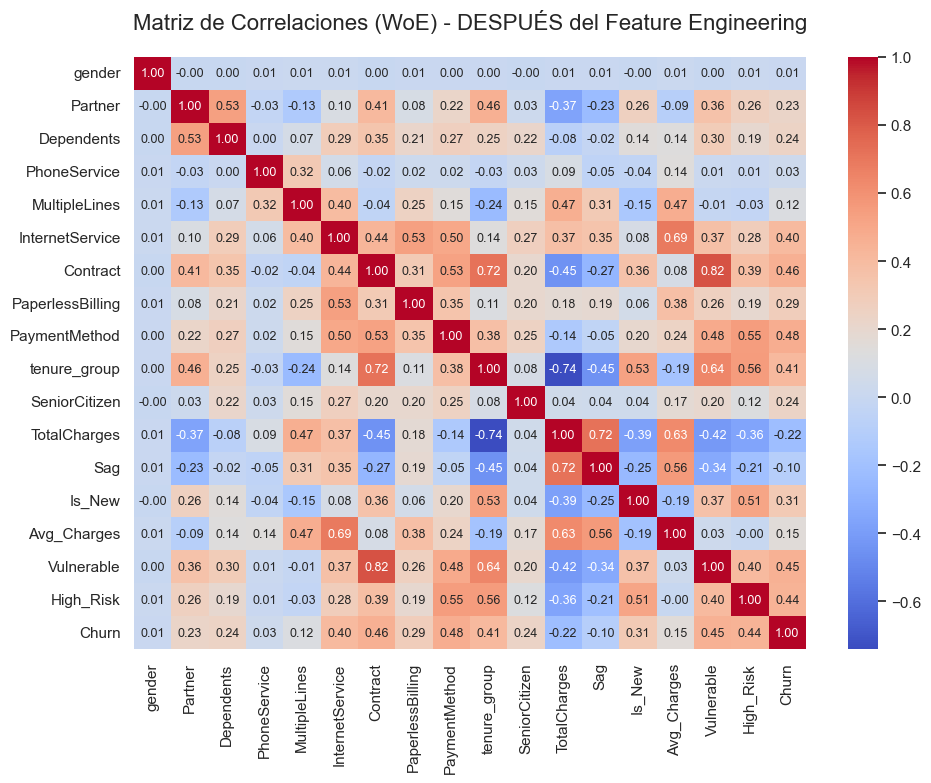


🔥 TOP 15 variables más correlacionadas con Churn:
Churn               1.000000
PaymentMethod       0.476173
Contract            0.458056
Vulnerable          0.449744
High_Risk           0.444542
tenure_group        0.412747
InternetService     0.403754
Is_New              0.307609
PaperlessBilling    0.285107
Dependents          0.240369
SeniorCitizen       0.236362
Partner             0.228212
TotalCharges        0.218365
Avg_Charges         0.151737
MultipleLines       0.115211
Name: Churn, dtype: float64


In [13]:

if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1}).astype(int)

y = df['Churn']
X = df.drop(columns=['Churn'])

#  Columnas automáticas
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()


# Preprocesador con WOE (versión correcta)
preprocessor = ColumnTransformer(
    transformers=[
        ('woe', WOEEncoder(regularization=1.0), cat_cols),   # ← Corrección aquí
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop'
)

#  Transformar
X_transformed = preprocessor.fit_transform(X, y)

#  Reconstruir DataFrame
df_en = pd.DataFrame(X_transformed, columns=cat_cols + num_cols)
df_en['Churn'] = y.reset_index(drop=True)

#  Corrección de infinitos (seguridad extra)
df_en = df_en.replace([np.inf, -np.inf], np.nan)
df_en = df_en.fillna(0)

# Matriz de correlación + Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_en.corr()


sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    annot_kws={"size": 9})



plt.title('Matriz de Correlaciones (WoE) - DESPUÉS del Feature Engineering',
          fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# 8. Ranking de variables
print("\n🔥 TOP 15 variables más correlacionadas con Churn:")
print(corr_matrix['Churn'].abs().sort_values(ascending=False).head(15))

## Conclusiones Finales de la Matriz de Correlación (WoE)


Al analizar la matriz de correlación después de aplicar la transformación de **Weight of Evidence (WoE)** y el Feature Engineering, se extraen las siguientes conclusiones estratégicas para el modelo:

* **Factores más fuertemente asociados al abandono:**  
  El método de pago **PaymentMethod** (*Electronic check*) presenta la correlación positiva más alta con *Churn* (~0.48), seguido muy de cerca por el tipo de contrato **Contract** (~0.46). Los contratos más cortos (*Month-to-month*) están asociados a mayor probabilidad de abandono.

* **Éxito de las variables sintéticas:**  
  Las características creadas mediante Feature Engineering demuestran un alto poder predictivo. Destacan especialmente **`Vulnerable`** (~0.45) y **`High_Risk`** (~0.44), que lograron capturar patrones de riesgo complejos que las variables originales no mostraban de forma aislada. La variable **`Sag`** (servicios agregados) también aporta valor moderado (~0.31).

* **Lealtad histórica:**  
  **`tenure_group`** muestra una correlación negativa clara con *Churn* (~ -0.41). Esto indica que a mayor antigüedad del cliente, menor es la probabilidad de abandono. De forma consistente, **`TotalCharges`** presenta una correlación negativa más moderada (~ -0.22).

* **Multicolinealidad persistente:**  
  Se mantiene una correlación alta entre **`InternetService`** y **`Avg_Charges`** (~0.69). Aunque se eliminó `MonthlyCharges` durante el Feature Engineering para mitigar redundancia, esta relación sigue presente y deberá ser monitoreada.

* **Variables de bajo impacto:**  
  Factores como **`gender`** (~0.01) y **`PhoneService`** (~0.03) muestran correlaciones prácticamente nulas con *Churn*, lo que permite considerar su eliminación o reducción de peso en el modelo final para evitar ruido innecesario.



---

## Competencia de Modelos Baseline.

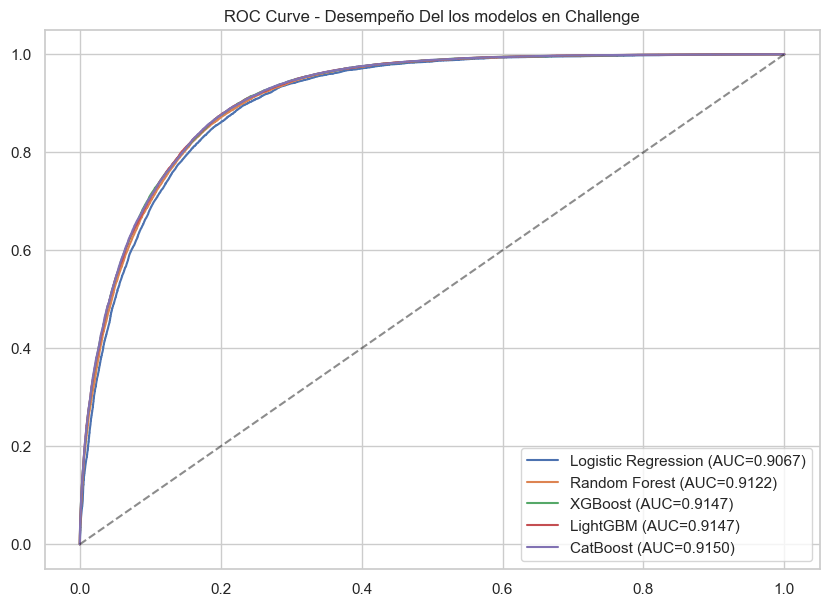

,Model,AUC Train,AUC Test,Diff,KS Test
4,CatBoost,0.9203,0.9150,0.0053,0.6765
3,LightGBM,0.9152,0.9147,0.0005,0.6771
2,XGBoost,0.9196,0.9147,0.0049,0.6763
1,Random Forest,0.9145,0.9122,0.0023,0.6715
0,Logistic Regression,0.9055,0.9067,-0.0012,0.6638


In [14]:
from sklearn import set_config
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, roc_curve

set_config(transform_output="pandas")

df_model = df.copy(deep=True)
y = df_model['Churn'].map({'No': 0, 'Yes': 1}) if df_model['Churn'].dtype == 'object' else df_model['Churn']
X = df_model.drop('Churn', axis=1)

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# PreProcesadores
preprocessor = ColumnTransformer(
    transformers=[
        ('woe_enc', WOEEncoder(), cat_cols),
        ('keep_num', 'passthrough', num_cols)
    ]
)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_test, X_out, y_test, y_out = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=555)

# Modeos Del Challenge
r_st = 555
models = {
    "Logistic Regression": Pipeline([
        ("pre", preprocessor),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=r_st))
    ]),
    "Random Forest": Pipeline([
        ("pre", preprocessor),
        ("model", RandomForestClassifier(max_depth=10, random_state=r_st))
    ]),
    "XGBoost": Pipeline([
        ("pre", preprocessor),
        ("model", XGBClassifier(random_state=r_st, eval_metric='logloss'))
    ]),
    "LightGBM": Pipeline([
        ("pre", preprocessor),
        ("model", LGBMClassifier(random_state=r_st, verbosity=-1))
    ]),
    "CatBoost": Pipeline([
        ("pre", preprocessor),
        ("model", CatBoostClassifier(random_state=r_st, verbose=0))
    ])
}

# Entrenamiento y Evaluación
results = []
plt.figure(figsize=(10, 7))

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_probs = model.predict_proba(X_train)[:, 1]
    y_test_probs = model.predict_proba(X_test)[:, 1]

    auc_train = roc_auc_score(y_train, y_train_probs)
    auc_test = roc_auc_score(y_test, y_test_probs)

    # KS
    fpr, tpr, _ = roc_curve(y_test, y_test_probs)
    ks_test = max(tpr - fpr)

    results.append({
        "Model": name,
        "AUC Train": round(auc_train, 4),
        "AUC Test": round(auc_test, 4),
        "Diff": round(auc_train - auc_test, 4),
        "KS Test": round(ks_test, 4)
    })

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_test:.4f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title("ROC Curve - Desempeño Del los modelos en Challenge")
plt.legend()
plt.show()


results_df = pd.DataFrame(results).sort_values("AUC Test", ascending=False)
display(results_df)

Luego de analizar la comptencia de modelos decidire trabajar con los modelos de boosting, para intentar sacar el mejor provecho a la prediccion de si es Churn o no. ahora procederemos a la busqueda de hiperparametros con gridSearch para hacer los primeros entrenamientos formales.

## GridSearch de HiperParametros.